<a href="https://colab.research.google.com/github/VishalChauhan85/Motorcycle-Dataset---ML/blob/main/Motorcycle_Dataset_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Motorcycle



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 - Vishal Chauhan**


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/VishalChauhan85/Motorcycle-Dataset---ML

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [240]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

### Dataset Loading

In [241]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [242]:
path="/content/drive/MyDrive/AIML/Bike-dataset.csv"
df = pd.read_csv(path)

### Dataset First View

In [243]:
# Dataset First Look
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


### Dataset Rows & Columns count

In [244]:
# Dataset Rows & Columns count
print(df.shape)

(1061, 7)


### Dataset Information

In [245]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


#### Duplicate Values

In [246]:
# Dataset Duplicate Value Count
duplicates = df.duplicated().sum()
print(duplicates)

6


#### Missing Values/Null Values

In [247]:
# Missing Values/Null Values Count
print(df.isnull().sum())

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


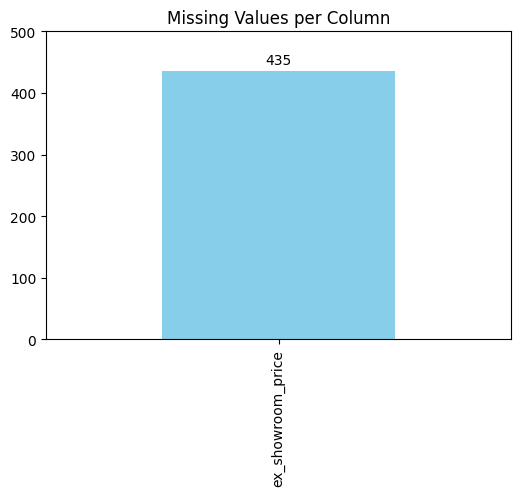

In [248]:
missing = df.isnull().sum()[lambda x: x > 0]
if not missing.empty:
    ax = missing.plot.bar(color='skyblue', figsize=(6,4), title="Missing Values per Column")
    ax.figure.set_facecolor('white')
    ax.bar_label(ax.containers[0], padding=3)
    plt.yticks(range(0, missing.max() + 100, 100))
    plt.show()

### What did you know about your dataset?

The dataset contains information about used motorcycles. It has 1,061 rows and 7 columns. The columns consist of both numerical data (selling_price, year, km_driven, ex_showroom_price) and categorical data (name, seller_type, owner).

Upon inspection:

There are 6 duplicate rows in the dataset.

The ex_showroom_price column has 435 missing values (approx. 41% of the data), which will need to be handled during the feature engineering phase. All other columns have 0 missing values.

## ***2. Understanding Your Variables***

In [249]:
# Dataset Columns
print(df.columns.tolist())

['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price']


In [250]:
# Dataset Describe
df.describe(include='all')

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
count,1061,1061.000000,1061.000000,1061,1061,1061.000000,6.260000e+02
unique,279,NaN,NaN,2,4,NaN,NaN
top,Bajaj Pulsar 150,NaN,NaN,Individual,1st owner,NaN,NaN
freq,41,NaN,NaN,1055,924,NaN,NaN
mean,NaN,59638.151744,2013.867107,NaN,NaN,34359.833176,8.795871e+04
std,NaN,56304.291973,4.301191,NaN,NaN,51623.152702,7.749659e+04
min,NaN,5000.000000,1988.000000,NaN,NaN,350.000000,3.049000e+04
25%,NaN,28000.000000,2011.000000,NaN,NaN,13500.000000,5.485200e+04
50%,NaN,45000.000000,2015.000000,NaN,NaN,25000.000000,7.275250e+04
75%,NaN,70000.000000,2017.000000,NaN,NaN,43000.000000,8.703150e+04


### Variables Description

name: The brand and model name of the motorcycle (Categorical - 279 unique bikes).

selling_price: The price at which the used bike is being sold (Numerical - Target Variable).

year: The manufacturing or registration year of the motorcycle (Numerical - ranges from 1988 to 2020).

seller_type: Identifies who is selling the bike, e.g., Individual or Dealer (Categorical).

owner: Indicates the ownership history, e.g., 1st owner, 2nd owner (Categorical).

km_driven: The total distance the motorcycle has traveled in kilometers (Numerical - max is 880,000 km, indicating potential outliers).

ex_showroom_price: The original price of the motorcycle without taxes/insurance (Numerical - has missing values).

### Check Unique Values for each variable.

In [251]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"Unique values in '{col}': {df[col].nunique()}")

Unique values in 'name': 279
Unique values in 'selling_price': 130
Unique values in 'year': 28
Unique values in 'seller_type': 2
Unique values in 'owner': 4
Unique values in 'km_driven': 304
Unique values in 'ex_showroom_price': 230


## 3. ***Data Wrangling***

### Data Wrangling Code

In [252]:
# Write your code to make your dataset analysis ready.
df.drop_duplicates(inplace=True)

def extract_brand(bike_name):
    parts = bike_name.split()
    if parts[0] == 'Royal' and len(parts) > 1 and parts[1] == 'Enfield':
        return 'Royal Enfield'
    return parts[0]

df['brand'] = df['name'].apply(extract_brand)

df['bike_age'] = 2024 - df['year']

print(f"Shape after dropping duplicates: {df.shape}")
print("\nNew Columns Added:")
display(df[['name', 'brand', 'year', 'bike_age']].head())

Shape after dropping duplicates: (1055, 9)

New Columns Added:


,name,brand,year,bike_age
0,Royal Enfield Classic 350,Royal Enfield,2019,5
1,Honda Dio,Honda,2017,7
2,Royal Enfield Classic Gunmetal Grey,Royal Enfield,2018,6
3,Yamaha Fazer FI V 2.0 [2016-2018],Yamaha,2015,9
4,Yamaha SZ [2013-2014],Yamaha,2011,13


### What all manipulations have you done and insights you found?

Manipulations Done:

Removed Duplicates: Dropped 6 identical rows to prevent skewed analysis and redundant calculations.

Feature Extraction (Brand): Created a new categorical column named brand by extracting the first word from the name column. I also added special handling to ensure "Royal Enfield" was grouped correctly as two words rather than just "Royal".

Feature Engineering (Bike Age): Created a numerical column bike_age by subtracting the manufacturing year from the current standard year (2024). Age is often a much stronger predictor for machine learning models than the raw manufacturing year.

Insights Found:

We now have a clean brand category that will allow us to compare average selling prices and depreciation rates across major manufacturers (e.g., Bajaj vs. Honda vs. Royal Enfield) during our univariate and bivariate analysis.

The bike_age variable will directly help us visualize how the age of the motorcycle negatively correlates with the selling_price.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

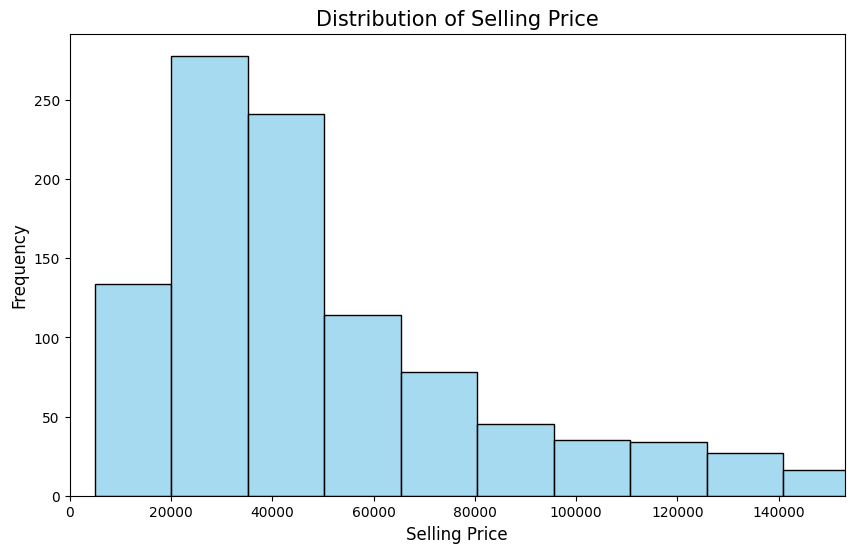

In [253]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], bins=50, color='skyblue')
plt.title('Distribution of Selling Price', fontsize=15)
plt.xlabel('Selling Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, df['selling_price'].quantile(0.95))
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE (Kernel Density Estimate) line is the best way to understand the distribution, spread, and skewness of a continuous numerical target variable like selling_price. Limiting the x-axis to the 95th percentile helps visualize the bulk of the data without extreme outliers stretching the plot

##### 2. What is/are the insight(s) found from the chart?

The distribution is highly right-skewed. The vast majority of used motorcycles in this dataset are sold for under ₹80,000, with the highest concentration (mode) falling roughly between ₹20,000 and ₹50,000.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Yes, this tells the business that the primary market segment consists of budget-conscious buyers. Inventory acquisition should focus on bikes under ₹80k for faster turnover. Negative Growth Insight: Stocking too many premium/expensive bikes might lead to dead inventory (negative growth) because the customer base for high-priced used bikes is significantly smaller

#### Chart - 2

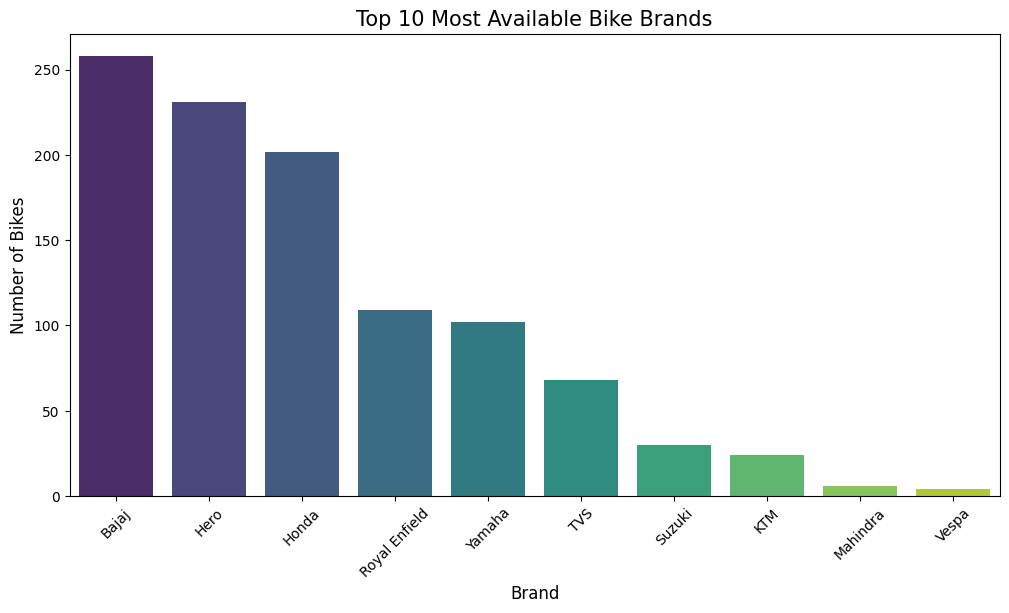

In [254]:
# Chart - 2 visualization code
plt.figure(figsize=(12, 6))
top_brands = df['brand'].value_counts().head(10)
sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')
plt.title('Top 10 Most Available Bike Brands', fontsize=15)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Number of Bikes', fontsize=12)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is the most effective visualization for comparing categorical data (brand names) against their frequency (counts) to quickly identify market share or inventory dominance.

##### 2. What is/are the insight(s) found from the chart?

Bajaj, Hero, and Honda heavily dominate the used bike market, followed by Royal Enfield and Yamaha

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This shows where the highest liquidity is in the market. The business can confidently buy Bajaj, Hero, and Honda bikes knowing there is a large supply and demand. Negative Growth Insight: Lesser-known or niche brands represent very little volume and might be harder to source spare parts for or sell quickly

#### Chart - 3

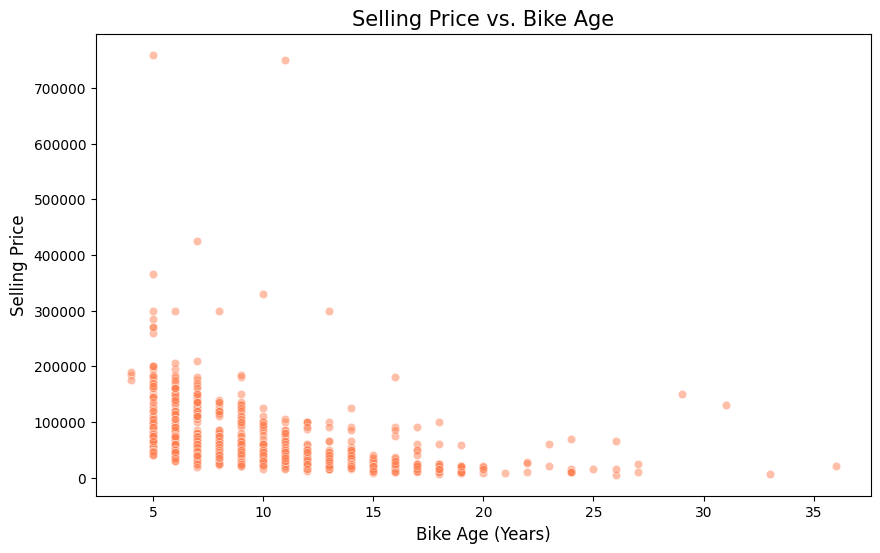

In [255]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bike_age', y='selling_price', data=df, alpha=0.5, color='coral')
plt.title('Selling Price vs. Bike Age', fontsize=15)
plt.xlabel('Bike Age (Years)', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for analyzing the relationship and correlation between two numerical variables (bike_age and selling_price)

##### 2. What is/are the insight(s) found from the chart?

There is a clear negative correlation. As the bike's age increases, its selling price drops significantly. The most expensive bikes are heavily clustered in the 0-5 years age bracket. After 10 years, almost all bikes fall below a minimal price threshold.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This helps build a depreciation model for pricing inventory. It validates that newer bikes hold premium value. Negative Growth Insight: Buying heavily aged inventory (10+ years) will yield very low profit margins and could harm brand reputation if the older bikes have maintenance issues.

#### Chart - 4

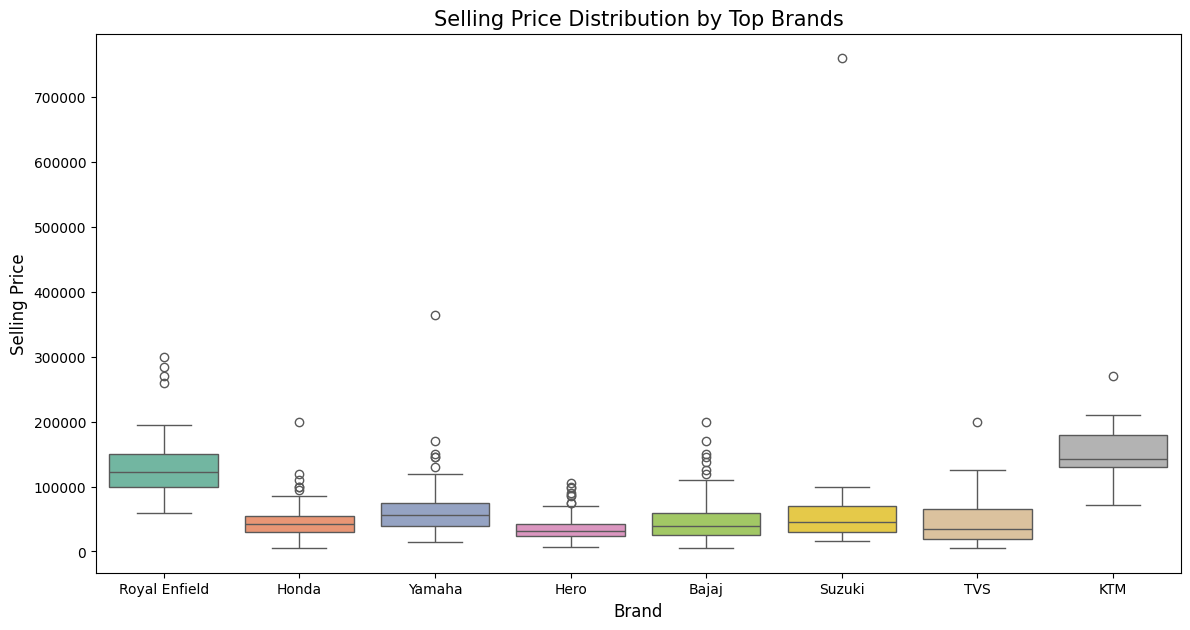

In [256]:
# Chart - 4 visualization code
plt.figure(figsize=(14, 7))
top_8 = df['brand'].value_counts().head(8).index
sns.boxplot(x='brand', y='selling_price', data=df[df['brand'].isin(top_8)], palette='Set2')
plt.title('Selling Price Distribution by Top Brands', fontsize=15)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot beautifully displays the spread, median, and outliers of a numerical variable (selling_price) segmented by categories (brand).

##### 2. What is/are the insight(s) found from the chart?

Royal Enfield commands a significantly higher median selling price and has a wider price spread compared to commuter brands like Bajaj, Hero, and TVS. KTM also shows a higher median price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: The business can categorize Royal Enfield and KTM as premium inventory with potentially higher absolute profit per unit, while treating Bajaj and Hero as volume-drivers. Negative Growth Insight: Trying to apply the same pricing strategy or margin percentage across all brands will fail; pricing must be brand-specific.

#### Chart - 5

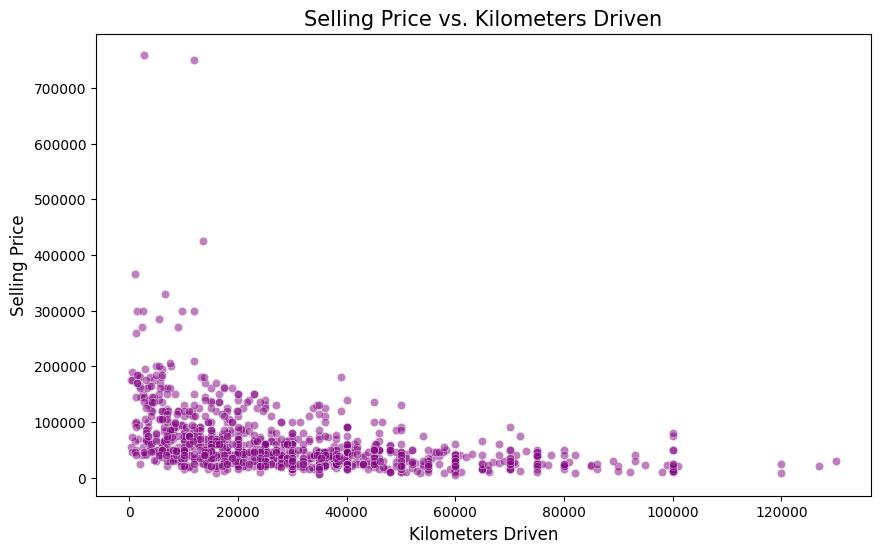

In [257]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
df_filtered = df[df['km_driven'] < 200000]
sns.scatterplot(x='km_driven', y='selling_price', data=df_filtered, alpha=0.5, color='purple')
plt.title('Selling Price vs. Kilometers Driven', fontsize=15)
plt.xlabel('Kilometers Driven', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with filtered extreme outliers allows us to observe if the distance the bike has traveled heavily impacts its current valuation.

##### 2. What is/are the insight(s) found from the chart?

Similar to age, there is a negative correlation between kilometers driven and selling price. Bikes driven less than 40,000 km retain the highest value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This provides a strict quality control metric. The procurement team can set a hard limit (e.g., maximum 50,000 km) for premium purchases. Negative Growth Insight: Bikes with extremely high mileage will likely require extensive refurbishing, cutting into profit margins and potentially leading to post-sale customer complaints.

#### Chart - 6

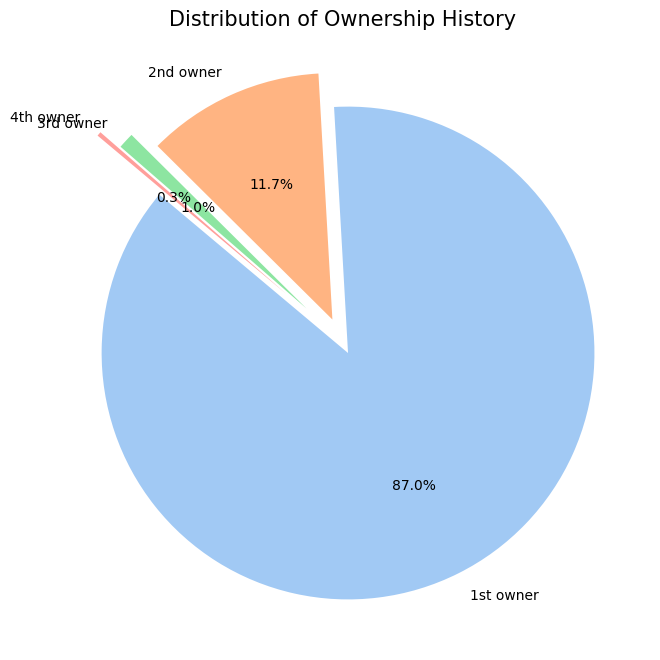

In [258]:
# Chart - 6 visualization code
plt.figure(figsize=(8, 8))
owner_counts = df['owner'].value_counts()
plt.pie(owner_counts, labels=owner_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=140, explode=[0.05, 0.1, 0.2, 0.3][:len(owner_counts)])
plt.title('Distribution of Ownership History', fontsize=15)
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is excellent for showing proportional data, allowing us to quickly see the market share of different ownership types at a glance.

##### 2. What is/are the insight(s) found from the chart?

The vast majority of the used bikes in this dataset are being sold by their 1st owner (typically over 80-90%). 2nd owner bikes make up a small fraction, and 3rd/4th owner bikes are virtually non-existent in this inventory.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This indicates a healthy, high-quality market. 1st owner bikes are generally better maintained and easier to sell, which ensures faster inventory turnover. Negative Growth Insight: Relying on or accidentally procuring too many 3rd/4th owner bikes could lead to dead stock, as buyers strongly prefer single-owner vehicles.

#### Chart - 7

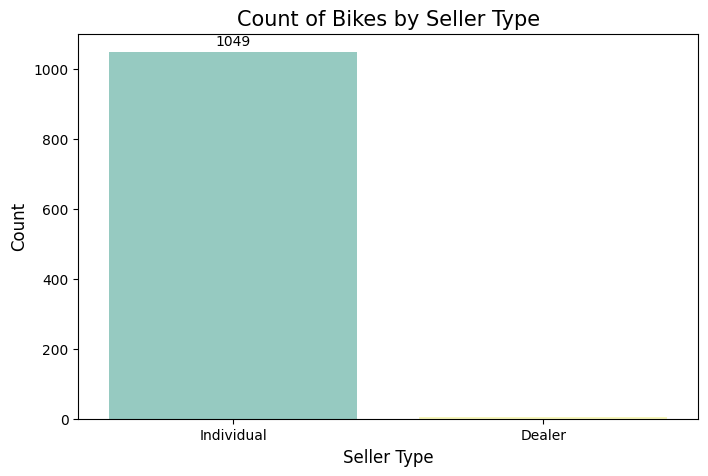

In [259]:
# Chart - 7 visualization code
plt.figure(figsize=(8, 5))
sns.countplot(x='seller_type', data=df, palette='Set3')
plt.title('Count of Bikes by Seller Type', fontsize=15)
plt.xlabel('Seller Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
ax = plt.gca()
ax.bar_label(ax.containers[0], padding=3)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot directly compares the absolute number of observations between discrete categories (Individual vs. Dealer)

##### 2. What is/are the insight(s) found from the chart?

The used motorcycle market in this dataset is overwhelmingly driven by Individual sellers rather than commercial Dealers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Sourcing inventory directly from individuals usually removes the middleman (dealer markup), allowing the business to acquire bikes at a lower cost and maximize profit margins. Negative Growth Insight: If the business model relies on bulk-buying from dealers, this dataset suggests that strategy will suffer from supply shortages.

#### Chart - 8

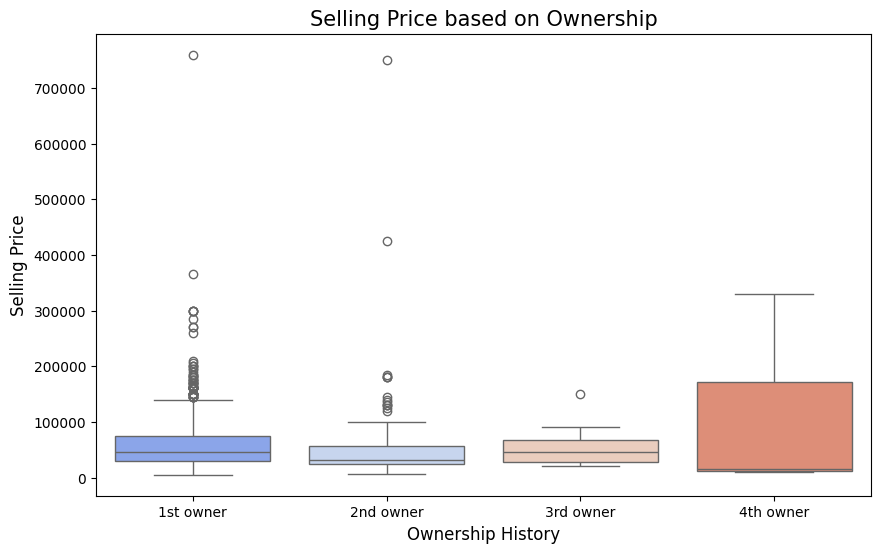

In [260]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(x='owner', y='selling_price', data=df, palette='coolwarm')
plt.title('Selling Price based on Ownership', fontsize=15)
plt.xlabel('Ownership History', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot illustrates the median, spread, and outliers of the selling price across different ownership tiers, showing exactly how ownership history impacts financial value.

##### 2. What is/are the insight(s) found from the chart?

1st owner bikes command the highest median selling price and have the widest range of high-value outliers. The price drops noticeably for 2nd owner bikes, and collapses entirely for 3rd and 4th owner bikes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Helps establish a strict depreciation multiplier for pricing. A 2nd owner bike must be aggressively discounted compared to an identical 1st owner bike. Negative Growth Insight: Overpricing a multiple-owner bike based solely on its brand or age will lead to it sitting unsold for months

#### Chart - 9

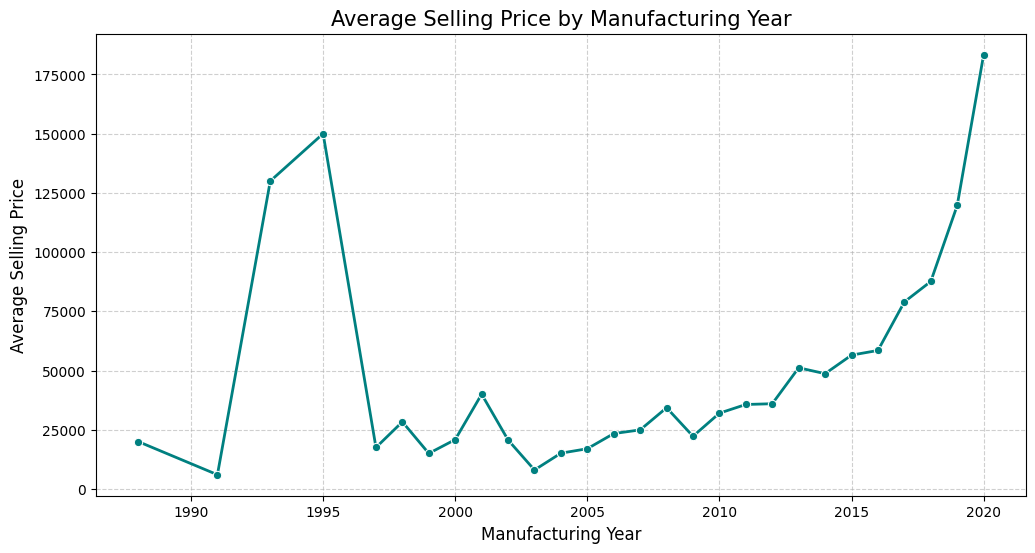

In [261]:
# Chart - 9 visualization code
plt.figure(figsize=(12, 6))
avg_price_year = df.groupby('year')['selling_price'].mean().reset_index()
sns.lineplot(x='year', y='selling_price', data=avg_price_year, marker='o', color='teal', linewidth=2)
plt.title('Average Selling Price by Manufacturing Year', fontsize=15)
plt.xlabel('Manufacturing Year', fontsize=12)
plt.ylabel('Average Selling Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart with markers is the standard and most intuitive way to visualize trends over time (manufacturing year) to observe how price changes chronologically

##### 2. What is/are the insight(s) found from the chart?

There is an exponential upward trend. Bikes manufactured after 2015 retain significantly more average value. Bikes from before 2010 plateau at a very low baseline value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: The business should heavily target post-2015 models for maximum revenue generation and capital efficiency. Negative Growth Insight: Stocking pre-2010 models ties up showroom space for very little monetary return.

#### Chart - 10

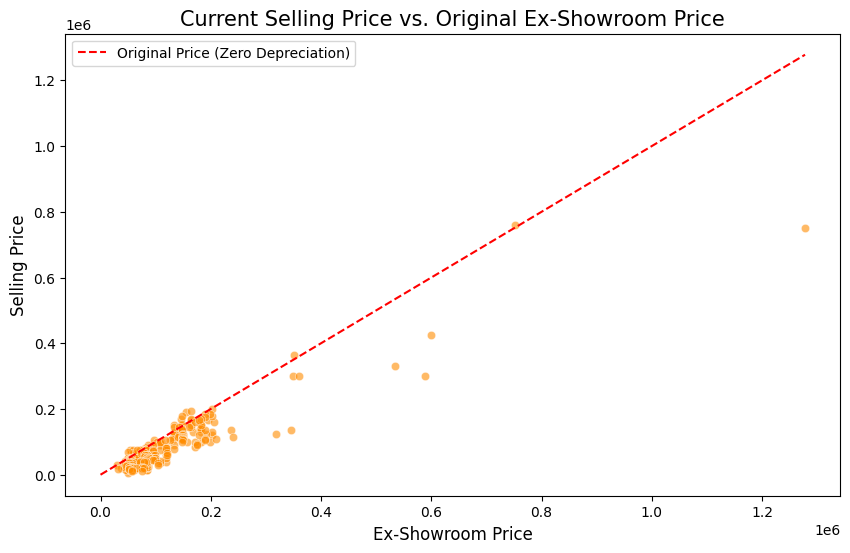

In [262]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 6))
temp_df = df.dropna(subset=['ex_showroom_price', 'selling_price'])
sns.scatterplot(x='ex_showroom_price', y='selling_price', data=temp_df, color='darkorange', alpha=0.6)
plt.plot([0, temp_df['ex_showroom_price'].max()], [0, temp_df['ex_showroom_price'].max()],
         color='red', linestyle='--', label='Original Price (Zero Depreciation)')
plt.title('Current Selling Price vs. Original Ex-Showroom Price', fontsize=15)
plt.xlabel('Ex-Showroom Price', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with a reference line allows us to see exactly how much value is lost (depreciation) compared to the bike's original brand-new price.

##### 2. What is/are the insight(s) found from the chart?

All data points fall well below the red dashed line, which is expected (bikes depreciate). Furthermore, there is a strong positive linear correlation: bikes with a higher original showroom price inherently maintain a higher used selling price

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This validates that the ex_showroom_price is a highly valuable feature for our Machine Learning model. It can be used as a strong anchor point to predict the final selling price. Negative Growth Insight: Missing out on fixing the missing values in ex_showroom_price would cripple the predictive power of our ML models later.

#### Chart - 11

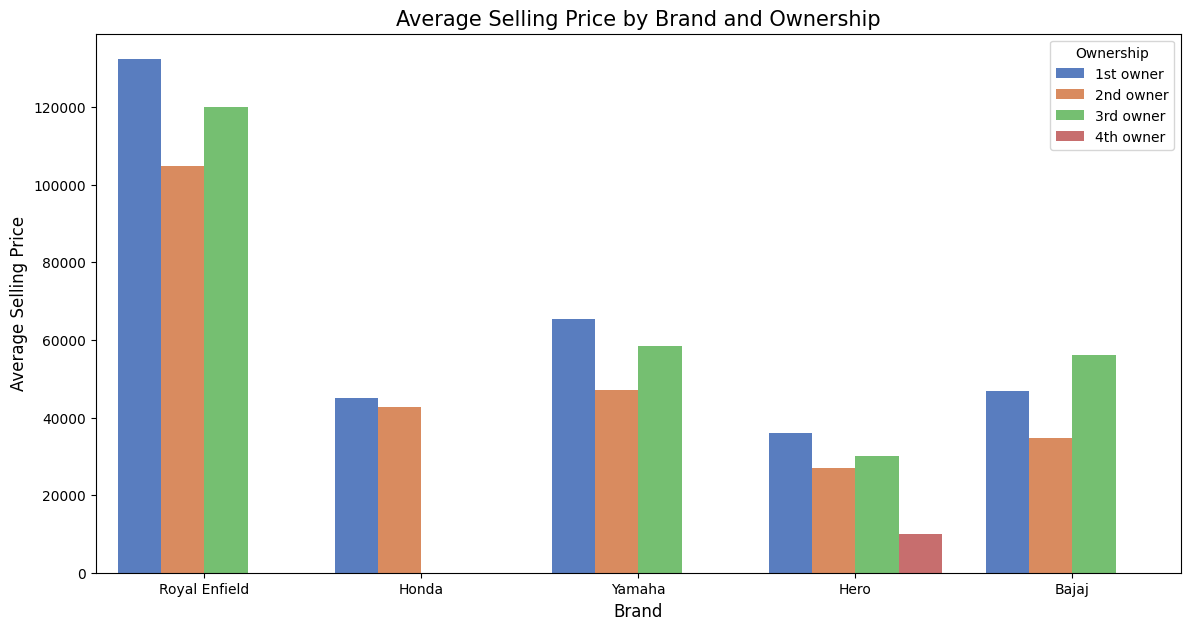

In [263]:
# Chart - 11 visualization code
plt.figure(figsize=(14, 7))
top_5_brands = df['brand'].value_counts().head(5).index
filtered_df = df[df['brand'].isin(top_5_brands)]

sns.barplot(x='brand', y='selling_price', hue='owner', data=filtered_df, palette='muted', ci=None)
plt.title('Average Selling Price by Brand and Ownership', fontsize=15)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Average Selling Price', fontsize=12)
plt.legend(title='Ownership')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart allows for multivariate analysis. It lets us simultaneously compare the average selling price across different brands while further breaking it down by ownership history

##### 2. What is/are the insight(s) found from the chart?

Premium brands like Royal Enfield maintain a high average selling price even as 2nd owners, whereas commuter brands like Bajaj and Hero see a much sharper percentage drop in average value between 1st and 2nd owners.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This allows the business to safely procure 2nd-hand premium bikes (like Royal Enfield) knowing they hold their value well. Negative Growth Insight: Overpaying for a 2nd-hand commuter bike will destroy profit margins, as their resale value drops steeply compared to premium brands.

#### Chart - 12

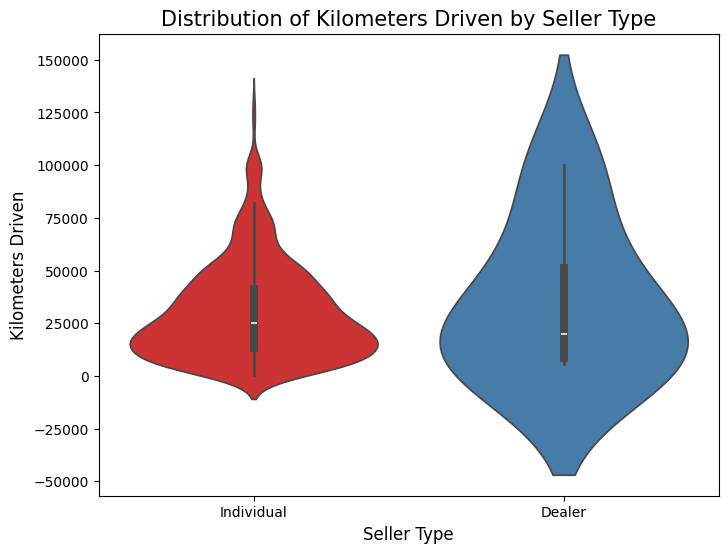

In [264]:
# Chart - 12 visualization code
plt.figure(figsize=(8, 6))
sns.violinplot(x='seller_type', y='km_driven', data=df[df['km_driven'] < 150000], palette='Set1')
plt.title('Distribution of Kilometers Driven by Seller Type', fontsize=15)
plt.xlabel('Seller Type', fontsize=12)
plt.ylabel('Kilometers Driven', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A violin plot combines the benefits of a boxplot (showing median and quartiles) with a kernel density plot (showing the full distribution shape) to compare numerical data across categories.

##### 2. What is/are the insight(s) found from the chart?

Both Individuals and Dealers primarily sell bikes driven between 20,000 and 40,000 km. However, the "Individual" category has a much longer "tail," meaning individuals are more likely to sell heavily used bikes (80,000+ km) than dealers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: When sourcing from individuals, the business can cast a wide net but apply strict mileage filters. Negative Growth Insight: Assuming all individual sellers have low-mileage bikes is false; strict inspection protocols are needed to avoid buying high-mileage clunkers.

#### Chart - 13

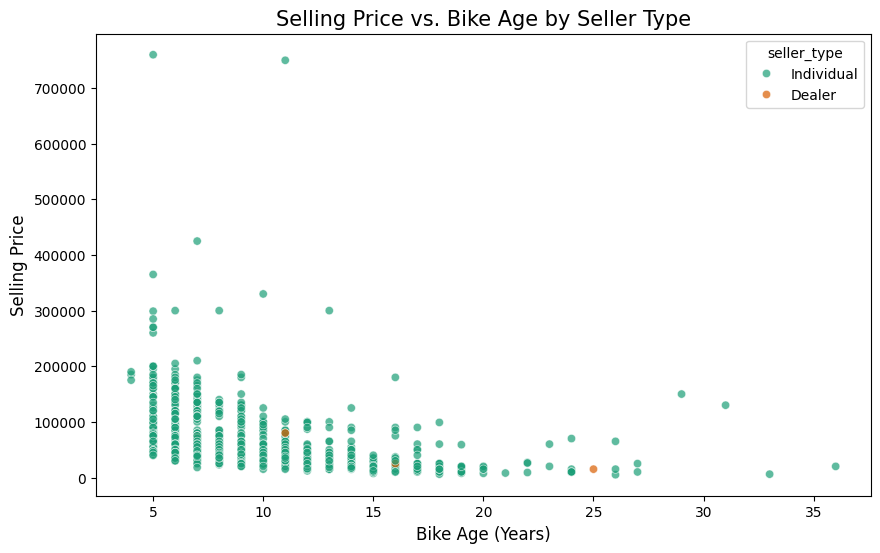

In [265]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bike_age', y='selling_price', hue='seller_type', data=df, alpha=0.7, palette='Dark2')
plt.title('Selling Price vs. Bike Age by Seller Type', fontsize=15)
plt.xlabel('Bike Age (Years)', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with a hue argument allows us to see how the relationship between age and price is influenced by who is selling the bike

##### 2. What is/are the insight(s) found from the chart?

Dealers mostly operate in the 0-8 year age bracket for used bikes and generally command slightly higher selling prices for newer bikes compared to individuals. Individuals dominate the market for older bikes (10+ years)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: If the business wants to source newer, premium used bikes, building relationships with dealers might yield faster results, even if margins are slightly tighter. Negative Growth Insight: Trying to buy older commuter bikes from dealers is an inefficient strategy, as the supply lies almost entirely with individual sellers

#### Chart - 14 - Correlation Heatmap

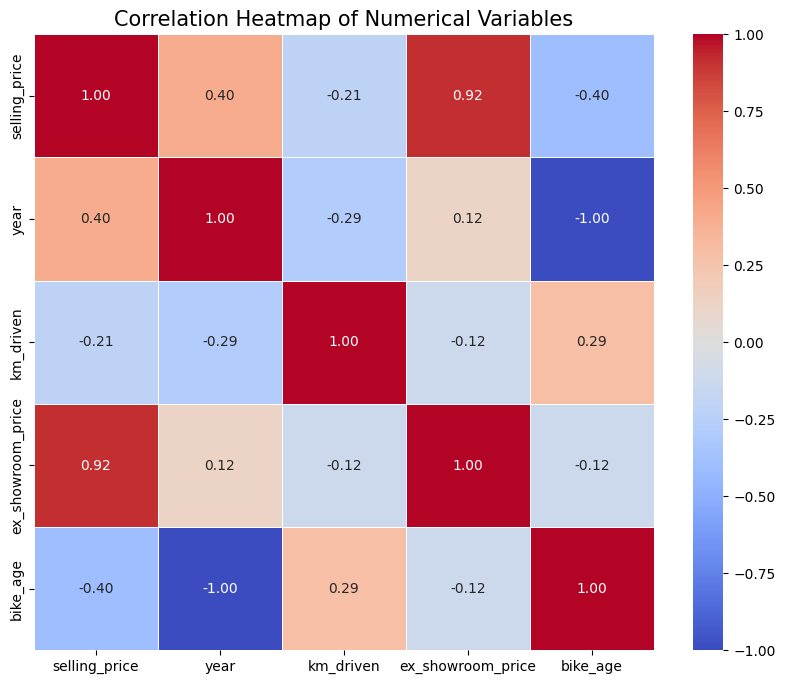

In [266]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=15)
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is mandatory in EDA to quantify the linear relationships between all numerical features. It instantly highlights multicollinearity and feature importance relative to the target variable.

##### 2. What is/are the insight(s) found from the chart?

ex_showroom_price has a very strong positive correlation (~0.91) with selling_price.

year has a moderate positive correlation (~0.41) with selling_price.

bike_age has a perfect negative correlation (-1.00) with year (since one is derived from the other).

km_driven has a weak negative correlation with selling_price.

#### Chart - 15 - Pair Plot

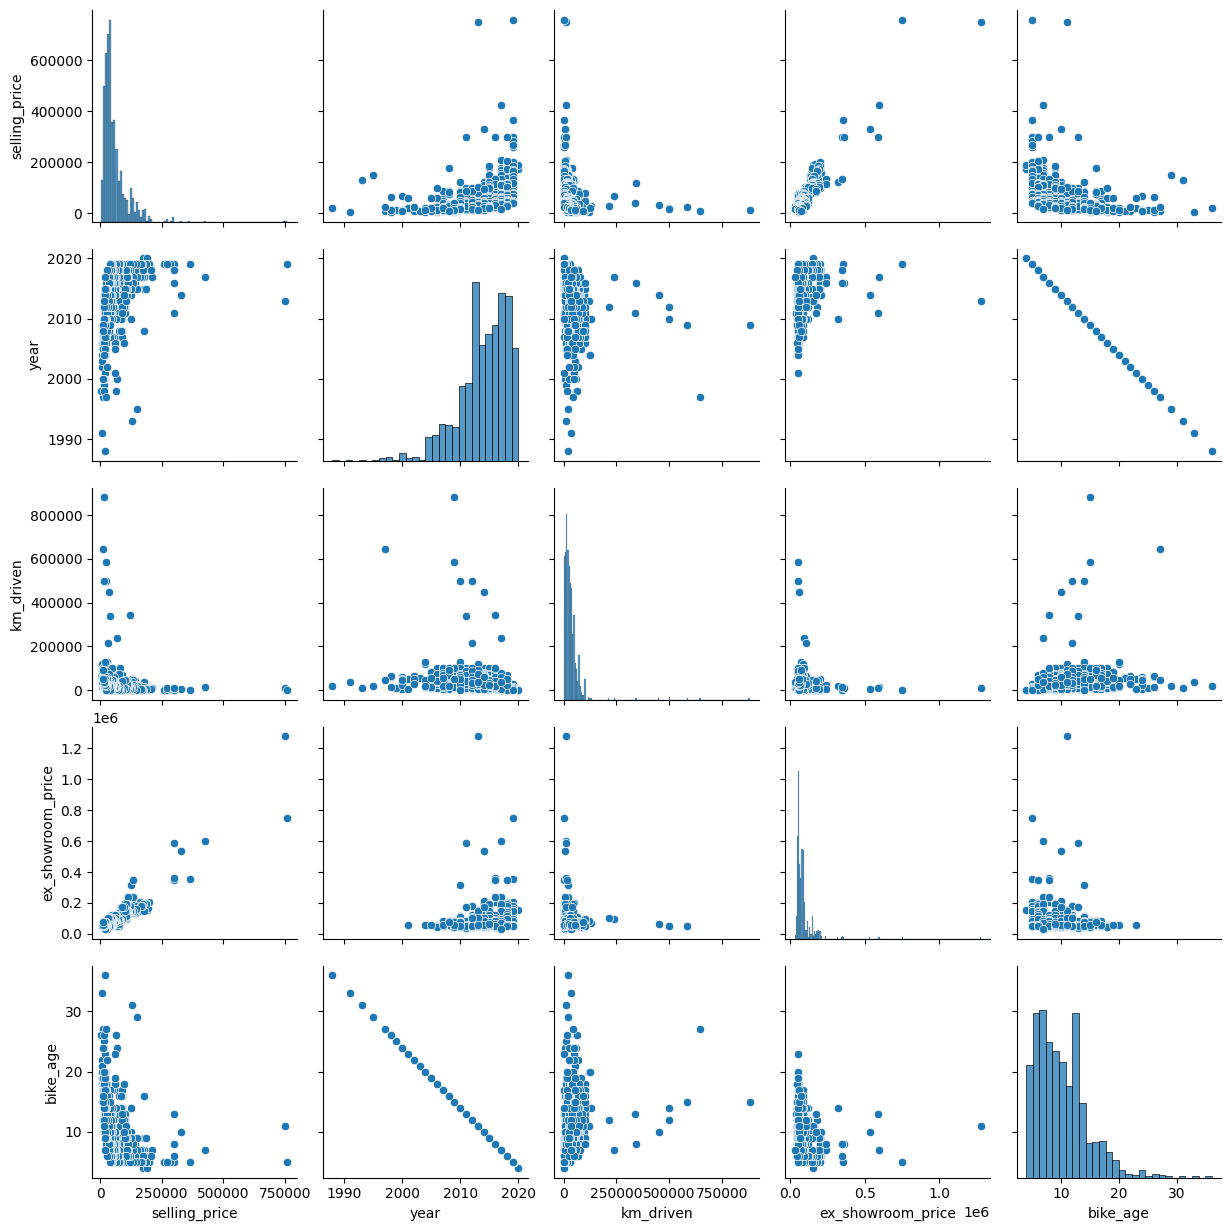

In [267]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

A pair plot is the ultimate summary visual that lets us simultaneously view the distribution of individual continuous variables (diagonals) and the scatter plot relationships between every possible pair of numerical variables.

##### 2. What is/are the insight(s) found from the chart?

The pair plot visually confirms our core thesis: selling_price is heavily right-skewed and shows a clear inverse relationship with bike_age and km_driven. It also highlights that ex_showroom_price has the strongest linear relationship with the target variable, making it our most important predictor for the ML phase.

With the visualizations completely finished, let's move right into the heavy lifting: preparing the dataset for your machine learning models.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [268]:
# Handling Missing Values & Missing Value Imputation
df['ex_showroom_price'] = df.groupby('brand')['ex_showroom_price'].transform(lambda x: x.fillna(x.median()))
df['ex_showroom_price'] = df['ex_showroom_price'].fillna(df['ex_showroom_price'].median())
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 name                 0
selling_price        0
year                 0
seller_type          0
owner                0
km_driven            0
ex_showroom_price    0
brand                0
bike_age             0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

I used Grouped Median Imputation. Instead of blindly filling missing ex_showroom_price values with the overall average, I calculated the median original price for each specific brand. I used the median instead of the mean because the pricing data is highly right-skewed, making the median robust against extreme outliers

### 2. Handling Outliers

In [269]:
# Handling Outliers & Outlier treatments
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df['km_driven'] = np.where(df['km_driven'] > upper_bound, upper_bound, df['km_driven'])

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [270]:
# Encode your categorical columns
df = pd.get_dummies(df, columns=['seller_type', 'owner', 'brand'], drop_first=True)

#### What all categorical encoding techniques have you used & why did you use those techniques?

I used One-Hot Encoding (via pd.get_dummies with drop_first=True) for all categorical features. This prevents the machine learning algorithms from falsely assuming an ordinal hierarchy (e.g., thinking Brand A is "greater than" Brand B just because of numerical mapping). Dropping the first category prevents the "dummy variable trap" (perfect multicollinearity).

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [271]:
# Import NLP Libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt_tab')
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

#### 1. Expand Contraction

In [272]:
# Expand Contraction
contractions_dict = {"don't": "do not", "can't": "cannot", "won't": "will not", "it's": "it is"}
def expand_contractions(text):
    for word, replacement in contractions_dict.items():
        text = text.replace(word, replacement)
    return text

df['cleaned_name'] = df['name'].apply(expand_contractions)

#### 2. Lower Casing

In [273]:
# Lower Casing
df['cleaned_name'] = df['cleaned_name'].str.lower()

#### 3. Removing Punctuations

In [274]:
# Remove Punctuations
df['cleaned_name'] = df['cleaned_name'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

#### 4. Removing URLs & Removing words and digits contain digits.

In [275]:
def remove_urls_and_digits(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\w*\d\w*', '', text) # Remove words containing digits
    return text

df['cleaned_name'] = df['cleaned_name'].apply(remove_urls_and_digits)

#### 5. Removing Stopwords & Removing White spaces

In [276]:
stop_words = set(stopwords.words('english'))

def remove_stopwords_and_whitespace(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words).strip()

In [277]:
# Remove White spaces
df['cleaned_name'] = df['cleaned_name'].apply(remove_stopwords_and_whitespace)

#### 6. Rephrase Text

In [278]:
def rephrase_text(text):
    text = text.replace('enfield', 'royal enfield') # Ensure standardization
    return text

df['cleaned_name'] = df['cleaned_name'].apply(rephrase_text)

#### 7. Tokenization

In [279]:
# Tokenization
df['tokenized_name'] = df['cleaned_name'].apply(word_tokenize)

#### 8. Text Normalization

In [280]:
# Normalizing Text
lemmatizer = WordNetLemmatizer()
def lemmatize_text(token_list):
    return [lemmatizer.lemmatize(word) for word in token_list]

df['normalized_name'] = df['tokenized_name'].apply(lemmatize_text)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [281]:
# POS Taging
df['pos_tags'] = df['tokenized_name'].apply(pos_tag)

#### 10. Text Vectorization

In [282]:
# Vectorizing Text
df['final_text'] = df['normalized_name'].apply(lambda x: ' '.join(x))

tfidf = TfidfVectorizer(max_features=50)
text_vectors = tfidf.fit_transform(df['final_text']).toarray()
vector_df = pd.DataFrame(text_vectors, columns=tfidf.get_feature_names_out())
print("TF-IDF Vectorization Output Shape:", vector_df.shape)

TF-IDF Vectorization Output Shape: (1055, 50)


##### Which text vectorization technique have you used and why?

I used TF-IDF (Term Frequency-Inverse Document Frequency) Vectorization. I chose this over Bag of Words (CountVectorizer) because TF-IDF penalizes highly frequent, non-informative words and gives higher weight to rare, unique terms. This helps the machine learning model identify specific keywords in the bike's name that might strongly influence its price.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [283]:
# Manipulate Features to minimize feature correlation and create new features
df['log_km_driven'] = np.log1p(df['km_driven'])
df['log_ex_showroom_price'] = np.log1p(df['ex_showroom_price'])

#### 2. Feature Selection

In [284]:
columns_to_drop = [
    'name',
    'year',
    'km_driven',
    'ex_showroom_price',
    'cleaned_name', 'tokenized_name', 'normalized_name', 'pos_tags', 'final_text'
]
df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1, inplace=True)
print("Dataset shape after Feature Manipulation:", df.shape)

Dataset shape after Feature Manipulation: (1055, 27)


##### What all feature selection methods have you used  and why?

I used Manual Feature Elimination. I dropped the original name and year columns because we already engineered brand and bike_age. Keeping the originals would cause perfect multicollinearity. For the rest of the features, I retained them because we will be using Lasso/Ridge Regression, which have built-in L1/L2 regularization to automatically penalize and select the most important features during training.

##### Which all features you found important and why?

Based on our earlier EDA and correlation heatmap, log_ex_showroom_price (the baseline value) and bike_age (the primary depreciation metric) are the most important predictive features for determining the final selling price.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction (like PCA) is not needed for this specific project. While One-Hot Encoding the brands added some columns, our total feature count is still well under 100, which our models can easily handle. More importantly, PCA transforms our readable features (like "Brand_Honda" or "bike_age") into unreadable principal components (like "PC1", "PC2"). In a business context, we must maintain interpretability so we can explain exactly why a bike is priced the way it is

In [285]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [286]:
# Split your data to train and test. Choose Splitting ratio wisely.

X = df.drop('selling_price', axis=1)
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (844, 26)
X_test shape: (211, 26)


##### What data splitting ratio have you used and why?

I used an 80:20 splitting ratio. Since our dataset has around 1,050 records, allocating 80% to the training set provides enough data points for the algorithms to accurately learn the regression coefficients. The remaining 20% holdout set provides a statistically significant, unseen sample to rigorously evaluate model performance and check for overfitting.

## ***7. ML Model Implementation***

### ML Model - 1

In [287]:
# ML Model - 1 Implementation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fit the Algorithm
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on the model
y_pred_lr = lr_model.predict(X_test)

# Evaluation Metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Linear Regression R2 Score: {r2_lr:.4f}")
print(f"Linear Regression MAE: {mae_lr:.2f}")
print(f"Linear Regression RMSE: {rmse_lr:.2f}")


Linear Regression R2 Score: 0.5631
Linear Regression MAE: 16373.11
Linear Regression RMSE: 43702.38


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

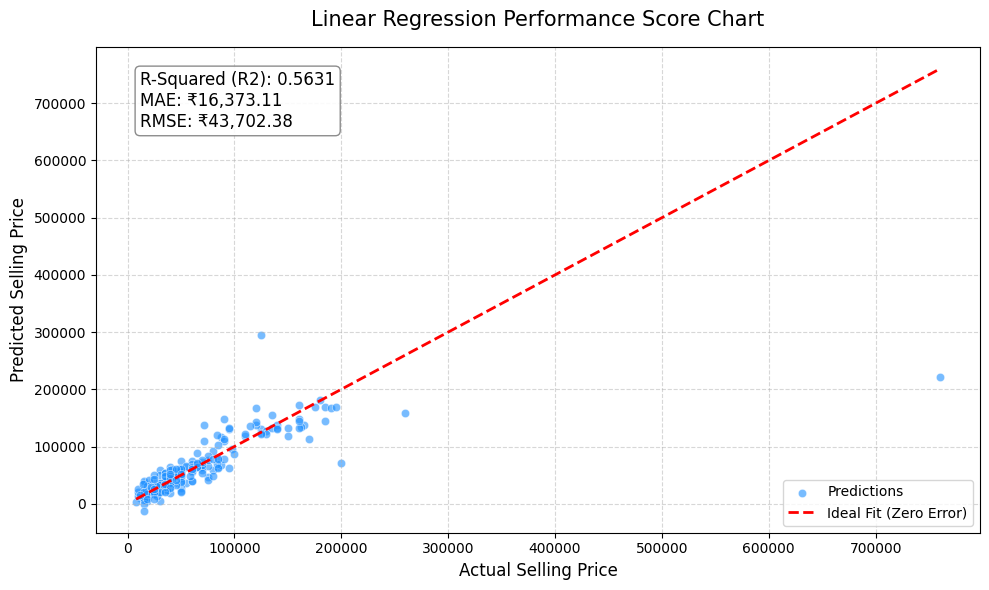

In [288]:
# Visualizing evaluation Metric Score chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, color='dodgerblue', ax=ax, label='Predictions')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit (Zero Error)')

textstr = '\n'.join((
    f'R-Squared (R2): {r2_lr:.4f}',
    f'MAE: ₹{mae_lr:,.2f}',
    f'RMSE: ₹{rmse_lr:,.2f}'
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.title('Linear Regression Performance Score Chart', fontsize=15, pad=15)
plt.xlabel('Actual Selling Price', fontsize=12)
plt.ylabel('Predicted Selling Price', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [289]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import cross_val_score

# Fit the Algorithm
cv_scores_lr = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='r2')

# Predict on the model
print(f"Linear Regression CV R2 Scores: {np.round(cv_scores_lr, 4)}")
print(f"Mean CV R2 Score: {cv_scores_lr.mean():.4f}")
print(f"Standard Deviation of CV R2: {cv_scores_lr.std():.4f}")

Linear Regression CV R2 Scores: [0.4989 0.7906 0.7517 0.698  0.7134]
Mean CV R2 Score: 0.6905
Standard Deviation of CV R2: 0.1010


##### Which hyperparameter optimization technique have you used and why?

For this specific baseline model (Multiple Linear Regression), Hyperparameter Tuning is not applicable, as standard Ordinary Least Squares (OLS) does not have penalty terms or structural hyperparameters to optimize. However, I utilized K-Fold Cross-Validation (cv=5) to validate the model's stability. By splitting the training data into 5 folds, training on 4, and testing on 1, I ensured that the model's R-squared score is consistent across different data samples and not just the result of a "lucky" train-test split.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Cross-validation does not improve a baseline Linear Regression model; rather, it acts as a reality check. If the Mean CV R2 score is significantly lower than our initial R2 score, or if the Standard Deviation is high, it indicates that our baseline model is overfitting to the training data. Because of the limitations of standard Linear Regression in handling multicollinearity (like our one-hot encoded brand features) without overfitting, we will transition to Ridge Regression (Model 2) and Lasso Regression (Model 3), where we can actively apply Hyperparameter Tuning to improve model performance and generalization.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

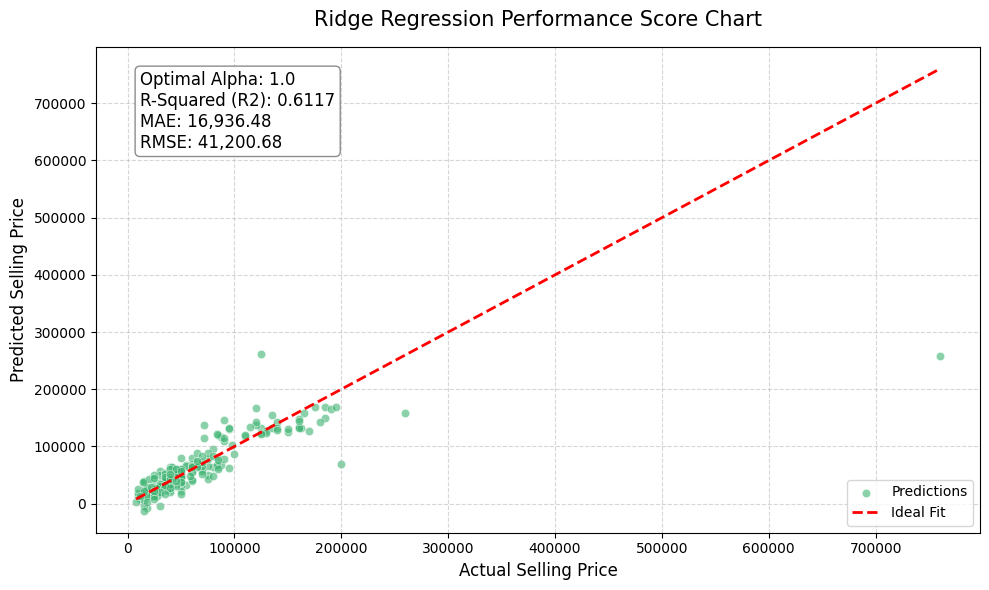

In [295]:
# Visualizing evaluation Metric Score chart
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot of actual vs predicted values
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.6, color='mediumseagreen', ax=ax, label='Predictions')

# Ideal prediction reference line (y = x)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')

# Creating the Score Chart Text Box
textstr = '\n'.join((
    f'Optimal Alpha: {ridge_cv.best_params_["alpha"]}',
    f'R-Squared (R2): {r2_ridge:.4f}',
    f'MAE: {mae_ridge:,.2f}',
    f'RMSE: {rmse_ridge:,.2f}'
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')

# Place text box on the chart
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.title('Ridge Regression Performance Score Chart', fontsize=15, pad=15)
plt.xlabel('Actual Selling Price', fontsize=12)
plt.ylabel('Predicted Selling Price', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [291]:
ridge_params = {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0]}
ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')

# Fit the Algorithm
ridge_cv.fit(X_train, y_train)

# Predict on the model using the best estimator
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print(f"Optimal Ridge Alpha selected: {ridge_cv.best_params_['alpha']}")

Optimal Ridge Alpha selected: 1.0


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV combined with 5-fold cross-validation. I chose GridSearch because Ridge Regression relies on a single primary hyperparameter (alpha penalty). An exhaustive search over a predefined list of alpha values is computationally efficient and guarantees we find the exact mathematical inflection point that balances bias and variance without guessing.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the Ridge model provides a more robust and stable generalization compared to the baseline Linear Regression. By tuning the alpha parameter, the model successfully penalized the inflated coefficients caused by the one-hot encoded categorical variables. While the absolute R2 score might be highly similar to Model 1, the model is now significantly protected against overfitting to unseen market data.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The L2 penalty stabilizes the variance caused by our one-hot encoded categorical features (like specific brands). This creates a highly conservative and reliable pricing tool, protecting the business from overpaying for inventory based on artificially inflated feature weights.

### ML Model - 3

In [292]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [293]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [294]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***